# ADNI slice timing consistency check

This notebook loads the ADNI metadata CSV, parses the `SLICETIMING` field, and checks whether the slice timing pattern is consistent overall and within each `MANUFACTURERSMODELNAME`.

The slice timing values are expected to be separated by underscores (`_`).

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')


In [15]:
CSV_PATH = Path('/home/martin/data_imaging/ADNIdata/StudyInfo_2024/MR_Image_Analysis/MAYOADIRL_MRI_FMRI_11_01_22_31May2023.csv')
REQUIRED_COLUMNS = ['SLICETIMING', 'MANUFACTURERSMODELNAME']

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df = df.copy()
df[REQUIRED_COLUMNS] = df[REQUIRED_COLUMNS].fillna('')

print(f'Loaded {len(df):,} rows from {CSV_PATH.name}')
df[REQUIRED_COLUMNS].head()

Loaded 2,908 rows from MAYOADIRL_MRI_FMRI_11_01_22_31May2023.csv


,SLICETIMING,MANUFACTURERSMODELNAME
0,43490.525_43489.035_43490.5875_43489.0975_4349...,Prisma_fit
1,47082.675_47082.235_47082.5275_47082.3075_4708...,Prisma_fit
2,52182.7425_52183.11_52182.8175_52182.9625_5218...,Prisma_fit
3,49670.0725_49669.6325_49669.9275_49669.7075_49...,Prisma_fit
4,40809.82_40809.38_40809.6725_40809.4525_40809....,Prisma_fit


In [16]:
def normalize_slice_timing(value: object) -> str:
    """Return a canonical underscore-separated slice timing pattern."""
    if pd.isna(value):
        return ''

    text = str(value).strip()
    if not text:
        return ''

    parts = [part.strip() for part in text.split('_') if part.strip() != '']
    return '_'.join(parts)


def parse_slice_timing_numbers(value: str) -> list[float]:
    """Parse normalized underscore-separated slice timing values into floats."""
    if not value:
        return []

    numbers = []
    for part in value.split('_'):
        try:
            numbers.append(float(part))
        except ValueError:
            return []
    return numbers


def slice_order_from_timing(values: list[float], one_based: bool = True) -> list[int]:
    """Return slice acquisition order from timing values using argsort indices."""
    if not values:
        return []

    sorted_idx = sorted(range(len(values)), key=lambda i: values[i])
    if one_based:
        return [idx + 1 for idx in sorted_idx]
    return sorted_idx


df['slice_timing_norm'] = df['SLICETIMING'].map(normalize_slice_timing)
df['slice_timing_tokens'] = df['slice_timing_norm'].str.split('_')
df['slice_timing_len'] = df['slice_timing_tokens'].map(lambda x: len(x) if isinstance(x, list) else 0)
df['has_slice_timing'] = df['slice_timing_norm'].ne('')

df['slice_timing_values'] = df['slice_timing_norm'].map(parse_slice_timing_numbers)
df['slice_order_1based'] = df['slice_timing_values'].map(lambda x: slice_order_from_timing(x, one_based=True))
df['slice_order_0based'] = df['slice_timing_values'].map(lambda x: slice_order_from_timing(x, one_based=False))
df['slice_order_key'] = df['slice_order_1based'].map(lambda x: '_'.join(map(str, x)) if x else '')

df[
    [
        'SLICETIMING',
        'slice_timing_norm',
        'slice_timing_len',
        'slice_order_1based',
        'MANUFACTURERSMODELNAME',
    ]
].head(10)


,SLICETIMING,slice_timing_norm,slice_timing_len,slice_order_1based,MANUFACTURERSMODELNAME
0,43490.525_43489.035_43490.5875_43489.0975_4349...,43490.525_43489.035_43490.5875_43489.0975_4349...,48,"[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 2...",Prisma_fit
1,47082.675_47082.235_47082.5275_47082.3075_4708...,47082.675_47082.235_47082.5275_47082.3075_4708...,64,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",Prisma_fit
2,52182.7425_52183.11_52182.8175_52182.9625_5218...,52182.7425_52183.11_52182.8175_52182.9625_5218...,64,"[7, 15, 23, 31, 39, 47, 55, 63, 5, 13, 21, 29,...",Prisma_fit
3,49670.0725_49669.6325_49669.9275_49669.7075_49...,49670.0725_49669.6325_49669.9275_49669.7075_49...,64,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",Prisma_fit
4,40809.82_40809.38_40809.6725_40809.4525_40809....,40809.82_40809.38_40809.6725_40809.4525_40809....,64,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",Prisma_fit
5,52101.8325_52101.3925_52101.685_52101.465_5210...,52101.8325_52101.3925_52101.685_52101.465_5210...,64,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",Prisma_fit
6,41986.28_41987.78_41986.3425_41987.8425_41986....,41986.28_41987.78_41986.3425_41987.8425_41986....,48,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25...",Achieva
7,52732.34_52733.84_52732.4025_52733.9025_52732....,52732.34_52733.84_52732.4025_52733.9025_52732....,48,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25...",Achieva
8,50173.5_50175_50173.5625_50175.0625_50173.625_...,50173.5_50175_50173.5625_50175.0625_50173.625_...,48,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25...",Achieva
9,49984.68_49986.18_49984.7425_49986.2425_49984....,49984.68_49986.18_49984.7425_49986.2425_49984....,48,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25...",Achieva


In [17]:
overall = {
    'rows_total': len(df),
    'rows_with_slice_timing': int(df['has_slice_timing'].sum()),
    'rows_without_slice_timing': int((~df['has_slice_timing']).sum()),
    'unique_slice_timing_patterns': int(df.loc[df['has_slice_timing'], 'slice_timing_norm'].nunique()),
    'unique_models': int(df['MANUFACTURERSMODELNAME'].replace('', pd.NA).nunique(dropna=True)),
}
overall

{'rows_total': 2908,
 'rows_with_slice_timing': 2908,
 'rows_without_slice_timing': 0,
 'unique_slice_timing_patterns': 2905,
 'unique_models': 20}

In [18]:
pattern_counts = (
    df.loc[df['has_slice_timing']]
      .groupby('slice_timing_norm')
      .size()
      .sort_values(ascending=False)
)

pattern_counts.head(20)

slice_timing_norm
38279.062_38280.562_38279.125_38280.625_38279.187_38280.687_38279.25_38280.75_38279.312_38280.812_38279.375_38280.875_38279.437_38280.937_38279.5_38281_38279.562_38281.062_38279.625_38281.125_38279.687_38281.187_38279.75_38281.25_38279.812_38281.312_38279.875_38281.375_38279.937_38281.437_38280_38281.5_38280.062_38281.562_38280.125_38281.625_38280.187_38281.687_38280.25_38281.75_38280.312_38281.812_38280.375_38281.875_38280.437_38281.937_38280.5_38282                                                                                                                                                                                    2
49927.1325_49925.645_49927.195_49925.705_49927.2575_49925.7675_49927.32_49925.83_49927.3825_49925.8925_49927.445_49925.955_49927.505_49926.0175_49927.5675_49926.0775_49927.63_49926.14_49927.6925_49926.2025_49927.755_49926.265_49927.8175_49926.3275_49927.8775_49926.39_49927.94_49926.45_49928.0025_49926.5125_49928.065_49926.575_49928.1275_49926.

In [19]:
model_summary = (
    df[df['has_slice_timing']]
    .groupby('MANUFACTURERSMODELNAME')
    .agg(
        n_images=('slice_timing_norm', 'size'),
        n_unique_timings=('slice_timing_norm', 'nunique'),
        n_unique_slice_orders=('slice_order_key', 'nunique'),
        timing_len_min=('slice_timing_len', 'min'),
        timing_len_max=('slice_timing_len', 'max'),
    )
    .sort_values(['n_unique_slice_orders', 'n_unique_timings', 'n_images'], ascending=[False, False, False])
)


def most_common_value(series: pd.Series) -> str:
    counts = series.value_counts(dropna=False)
    return counts.index[0] if len(counts) else ''


model_mode_timing = (
    df[df['has_slice_timing']]
    .groupby('MANUFACTURERSMODELNAME')['slice_timing_norm']
    .agg(most_common_value)
    .rename('most_common_timing')
)

model_mode_order = (
    df[df['has_slice_timing']]
    .groupby('MANUFACTURERSMODELNAME')['slice_order_key']
    .agg(most_common_value)
    .rename('most_common_slice_order')
)

model_mode_count = (
    df[df['has_slice_timing']]
    .groupby(['MANUFACTURERSMODELNAME', 'slice_order_key'])
    .size()
    .rename('order_count')
    .reset_index()
    .sort_values(['MANUFACTURERSMODELNAME', 'order_count'], ascending=[True, False])
    .groupby('MANUFACTURERSMODELNAME')
    .first()
)

model_summary = model_summary.join(model_mode_timing).join(model_mode_order).join(
    model_mode_count['order_count'].rename('most_common_order_count')
)
model_summary['most_common_order_share'] = model_summary['most_common_order_count'] / model_summary['n_images']
model_summary['n_rows_not_matching_common_order'] = model_summary['n_images'] - model_summary['most_common_order_count']

model_summary.sort_values(
    ['n_unique_slice_orders', 'n_unique_timings', 'n_images'],
    ascending=[False, False, False],
)


,n_images,n_unique_timings,n_unique_slice_orders,timing_len_min,timing_len_max,most_common_timing,most_common_slice_order,most_common_order_count,most_common_order_share,n_rows_not_matching_common_order
MANUFACTURERSMODELNAME,,,,,,,,,,
Achieva,556,556,6,36,48,68198.28_68199.78_68198.3425_68199.8425_68198....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,532,0.956835,24
Prisma,229,228,5,48,64,49927.1325_49925.645_49927.195_49925.705_49927...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,115,0.502183,114
Prisma_fit,599,599,4,48,64,37434.74_37434.3_37434.595_37434.375_37434.667...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,360,0.601002,239
Skyra,138,138,4,48,72,52757.81_52756.31_52757.8725_52756.3725_52757....,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,111,0.804348,27
Signa_HDxt,19,19,4,44,49,45321.062_45322.562_45321.125_45322.625_45321....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,16,0.842105,3
DISCOVERY_MR750,350,349,3,46,48,38279.062_38280.562_38279.125_38280.625_38279....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,348,0.994286,2
Intera,199,199,3,36,48,53982.54_53984.04_53982.6025_53984.1025_53982....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,189,0.949749,10
Ingenia,197,197,2,48,80,34265.12_34266.62_34265.1825_34266.6825_34265....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,196,0.994924,1
Verio,135,135,2,43,48,37134.0125_37132.5075_37134.075_37132.57_37134...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,134,0.992593,1


In [20]:
inconsistent_models = model_summary[model_summary['n_unique_timings'] > 1].copy()
inconsistent_models

,n_images,n_unique_timings,n_unique_slice_orders,timing_len_min,timing_len_max,most_common_timing,most_common_slice_order,most_common_order_count,most_common_order_share,n_rows_not_matching_common_order
MANUFACTURERSMODELNAME,,,,,,,,,,
Achieva,556,556,6,36,48,68198.28_68199.78_68198.3425_68199.8425_68198....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,532,0.956835,24
Prisma,229,228,5,48,64,49927.1325_49925.645_49927.195_49925.705_49927...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,115,0.502183,114
Prisma_fit,599,599,4,48,64,37434.74_37434.3_37434.595_37434.375_37434.667...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,360,0.601002,239
Skyra,138,138,4,48,72,52757.81_52756.31_52757.8725_52756.3725_52757....,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,111,0.804348,27
Signa_HDxt,19,19,4,44,49,45321.062_45322.562_45321.125_45322.625_45321....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,16,0.842105,3
DISCOVERY_MR750,350,349,3,46,48,38279.062_38280.562_38279.125_38280.625_38279....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,348,0.994286,2
Intera,199,199,3,36,48,53982.54_53984.04_53982.6025_53984.1025_53982....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,189,0.949749,10
Ingenia,197,197,2,48,80,34265.12_34266.62_34265.1825_34266.6825_34265....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,196,0.994924,1
Verio,135,135,2,43,48,37134.0125_37132.5075_37134.075_37132.57_37134...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,134,0.992593,1


/tmp/ipykernel_2082909/577863411.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


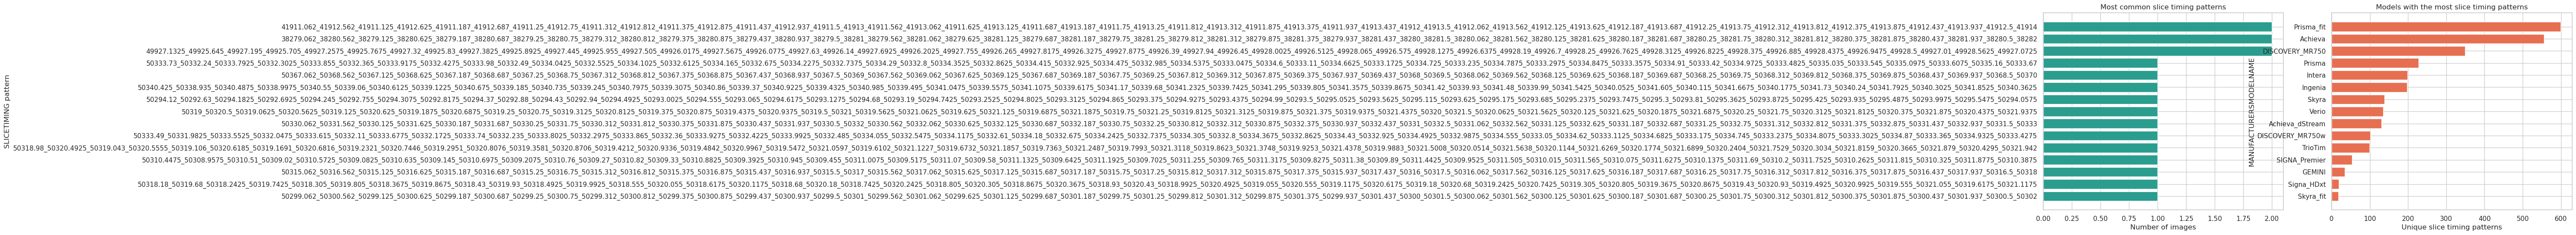

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_patterns = pattern_counts.head(15).sort_values()
axes[0].barh(top_patterns.index, top_patterns.values, color='#2a9d8f')
axes[0].set_title('Most common slice timing patterns')
axes[0].set_xlabel('Number of images')
axes[0].set_ylabel('SLICETIMING pattern')

model_plot = model_summary.sort_values('n_unique_timings', ascending=True).tail(15)
axes[1].barh(model_plot.index.astype(str), model_plot['n_unique_timings'], color='#e76f51')
axes[1].set_title('Models with the most slice timing patterns')
axes[1].set_xlabel('Unique slice timing patterns')
axes[1].set_ylabel('MANUFACTURERSMODELNAME')

plt.tight_layout()
plt.show()

In [23]:
def preview_model(model_name: str, n: int = 10) -> pd.DataFrame:
    return (
        df[df['MANUFACTURERSMODELNAME'] == model_name]
        [['MANUFACTURERSMODELNAME', 'SLICETIMING', 'slice_timing_norm']]
        .head(n)
    )

if not inconsistent_models.empty:
    example_model = inconsistent_models.index[0]
    print(f'Example inconsistent model: {example_model}')
    display(preview_model(example_model, n=20))
else:
    print('No model shows more than one slice timing pattern.')

Example inconsistent model: Achieva


,MANUFACTURERSMODELNAME,SLICETIMING,slice_timing_norm
6,Achieva,41986.28_41987.78_41986.3425_41987.8425_41986....,41986.28_41987.78_41986.3425_41987.8425_41986....
7,Achieva,52732.34_52733.84_52732.4025_52733.9025_52732....,52732.34_52733.84_52732.4025_52733.9025_52732....
8,Achieva,50173.5_50175_50173.5625_50175.0625_50173.625_...,50173.5_50175_50173.5625_50175.0625_50173.625_...
9,Achieva,49984.68_49986.18_49984.7425_49986.2425_49984....,49984.68_49986.18_49984.7425_49986.2425_49984....
10,Achieva,37353.78_37355.28_37353.8425_37355.3425_37353....,37353.78_37355.28_37353.8425_37355.3425_37353....
13,Achieva,36836.93_36838.43_36836.9925_36838.4925_36837....,36836.93_36838.43_36836.9925_36838.4925_36837....
18,Achieva,34844.1_34845.6_34844.1625_34845.6625_34844.22...,34844.1_34845.6_34844.1625_34845.6625_34844.22...
19,Achieva,48592.68_48594.18_48592.7425_48594.2425_48592....,48592.68_48594.18_48592.7425_48594.2425_48592....
23,Achieva,43954.71_43956.21_43954.7725_43956.2725_43954....,43954.71_43956.21_43954.7725_43956.2725_43954....
24,Achieva,50162.51_50164.01_50162.5725_50164.0725_50162....,50162.51_50164.01_50162.5725_50164.0725_50162....


In [24]:
def modal_value(series: pd.Series) -> str:
    counts = series.value_counts(dropna=False)
    return counts.index[0] if len(counts) else ''

# Global norm: most common slice order in the full dataset (excluding empty orders)
global_norm_slice_order = modal_value(df.loc[df['slice_order_key'] != '', 'slice_order_key'])

# Model norm: most common slice order for each MANUFACTURERSMODELNAME
model_norm_slice_order = (
    df[df['slice_order_key'] != '']
    .groupby('MANUFACTURERSMODELNAME')['slice_order_key']
    .agg(modal_value)
    .rename('model_norm_slice_order')
)

# Attach norms and consistency flags to each row
df = df.join(model_norm_slice_order, on='MANUFACTURERSMODELNAME')
df['global_norm_slice_order'] = global_norm_slice_order

df['matches_global_norm'] = (
    (df['slice_order_key'] != '') &
    (df['slice_order_key'] == df['global_norm_slice_order'])
)

df['matches_model_norm'] = (
    (df['slice_order_key'] != '') &
    (df['slice_order_key'] == df['model_norm_slice_order'])
)

df['inconsistent_vs_global_norm'] = (df['slice_order_key'] != '') & (~df['matches_global_norm'])
df['inconsistent_vs_model_norm'] = (df['slice_order_key'] != '') & (~df['matches_model_norm'])

norm_summary = {
    'global_norm_slice_order': global_norm_slice_order,
    'rows_with_slice_order': int((df['slice_order_key'] != '').sum()),
    'rows_consistent_with_global_norm': int(df['matches_global_norm'].sum()),
    'rows_inconsistent_with_global_norm': int(df['inconsistent_vs_global_norm'].sum()),
    'rows_consistent_with_model_norm': int(df['matches_model_norm'].sum()),
    'rows_inconsistent_with_model_norm': int(df['inconsistent_vs_model_norm'].sum()),
}

inconsistency_by_model = (
    df[df['slice_order_key'] != '']
    .groupby('MANUFACTURERSMODELNAME')
    .agg(
        n_images=('slice_order_key', 'size'),
        model_norm_slice_order=('model_norm_slice_order', 'first'),
        n_consistent_model_norm=('matches_model_norm', 'sum'),
        n_inconsistent_model_norm=('inconsistent_vs_model_norm', 'sum'),
        n_consistent_global_norm=('matches_global_norm', 'sum'),
        n_inconsistent_global_norm=('inconsistent_vs_global_norm', 'sum'),
    )
)

inconsistency_by_model['pct_inconsistent_model_norm'] = (
    inconsistency_by_model['n_inconsistent_model_norm'] / inconsistency_by_model['n_images']
)
inconsistency_by_model['pct_inconsistent_global_norm'] = (
    inconsistency_by_model['n_inconsistent_global_norm'] / inconsistency_by_model['n_images']
)

inconsistency_by_model = inconsistency_by_model.sort_values(
    ['n_inconsistent_model_norm', 'n_inconsistent_global_norm', 'n_images'],
    ascending=[False, False, False],
)

inconsistent_rows_preview = df[df['inconsistent_vs_model_norm']].copy()
columns_preview = [
    'MANUFACTURERSMODELNAME',
    'SLICETIMING',
    'slice_order_1based',
    'slice_order_key',
    'model_norm_slice_order',
]

print(norm_summary)
display(inconsistency_by_model.head(20))
display(inconsistent_rows_preview[columns_preview].head(30))

{'global_norm_slice_order': '1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_35_37_39_41_43_45_47_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34_36_38_40_42_44_46_48', 'rows_with_slice_order': 2908, 'rows_consistent_with_global_norm': 1636, 'rows_inconsistent_with_global_norm': 1272, 'rows_consistent_with_model_norm': 2484, 'rows_inconsistent_with_model_norm': 424}


,n_images,model_norm_slice_order,n_consistent_model_norm,n_inconsistent_model_norm,n_consistent_global_norm,n_inconsistent_global_norm,pct_inconsistent_model_norm,pct_inconsistent_global_norm
MANUFACTURERSMODELNAME,,,,,,,,
Prisma_fit,599,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,360,239,0,599,0.398998,1.000000
Prisma,229,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,115,114,0,229,0.497817,1.000000
Skyra,138,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,111,27,0,138,0.195652,1.000000
Achieva,556,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,532,24,532,24,0.043165,0.043165
Intera,199,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,189,10,189,10,0.050251,0.050251
Signa_HDxt,19,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,16,3,16,3,0.157895,0.157895
DISCOVERY_MR750,350,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,348,2,348,2,0.005714,0.005714
GEMINI,35,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,33,2,33,2,0.057143,0.057143
Verio,135,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,134,1,0,135,0.007407,1.000000


,MANUFACTURERSMODELNAME,SLICETIMING,slice_order_1based,slice_order_key,model_norm_slice_order
1,Prisma_fit,47082.675_47082.235_47082.5275_47082.3075_4708...,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...
2,Prisma_fit,52182.7425_52183.11_52182.8175_52182.9625_5218...,"[7, 15, 23, 31, 39, 47, 55, 63, 5, 13, 21, 29,...",7_15_23_31_39_47_55_63_5_13_21_29_37_45_53_61_...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...
3,Prisma_fit,49670.0725_49669.6325_49669.9275_49669.7075_49...,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...
4,Prisma_fit,40809.82_40809.38_40809.6725_40809.4525_40809....,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...
5,Prisma_fit,52101.8325_52101.3925_52101.685_52101.465_5210...,"[2, 10, 18, 26, 34, 42, 50, 58, 4, 12, 20, 28,...",2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...
25,Prisma,51310.5225_51309.0325_51310.5825_51309.095_513...,"[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 2...",2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...
29,Prisma,51918.6125_51917.1225_51918.675_51917.185_5191...,"[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 2...",2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...
38,Verio,49429.3875_49430.9275_49429.4575_49430.9975_49...,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25...",1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...
40,Prisma,37017.445_37015.955_37017.5075_37016.0175_3701...,"[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 2...",2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...
44,DISCOVERY_MR750,39107.063_39108.595_39107.127_39108.659_39107....,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25...",1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...


## How to read the results

- `overall` shows whether the dataset contains slice timing values and how many distinct patterns exist.
- `pattern_counts` tells you which slice timing layouts are most frequent.
- `slice_order_1based` (in the preview table) is the slice acquisition order computed by sorting timing values and taking the sorted indices.
- `model_summary` includes both timing-pattern consistency (`n_unique_timings`) and derived slice-order consistency (`n_unique_slice_orders`) for each `MANUFACTURERSMODELNAME`.
- `norm_summary` defines the global slice-order norm and reports how many rows are consistent/inconsistent against global and model-specific norms.
- `inconsistency_by_model` ranks models by inconsistency rate against the model norm and global norm.
- `inconsistent_rows_preview` shows concrete rows that deviate from their model norm.


## RID list for inconsistent Achieva and Intera scans

This section lists subject RIDs for rows flagged as inconsistent against the model norm, restricted to scanner models containing `Achieva` or `Intera`.

In [26]:
rid_candidates = ['RID', 'Image Data ID', 'IMAGEUID', 'IMAGE_ID']
rid_col = next((c for c in rid_candidates if c in df.columns), None)

if rid_col is None:
    print('RID column not found. Available columns include:')
    display(pd.Index(df.columns))
else:
    model_mask = df['MANUFACTURERSMODELNAME'].str.contains('Achieva|Intera', case=False, na=False)
    inconsistent_mask = df['inconsistent_vs_model_norm']

    achieva_intera_inconsistent = df[model_mask & inconsistent_mask].copy()

    rid_report = (
        achieva_intera_inconsistent[
            ['MANUFACTURERSMODELNAME', rid_col, 'slice_order_key', 'model_norm_slice_order', 'SLICETIMING']
        ]
        .rename(columns={rid_col: 'RID'})
        .drop_duplicates(subset=['MANUFACTURERSMODELNAME', 'RID'])
        .sort_values(['MANUFACTURERSMODELNAME', 'RID'])
        .reset_index(drop=True)
    )

    print(f'Total inconsistent Achieva/Intera rows: {len(achieva_intera_inconsistent):,}')
    print(f'Unique RIDs in Achieva/Intera inconsistent rows: {rid_report["RID"].nunique():,}')
    display(rid_report)

    display(
        rid_report.groupby('MANUFACTURERSMODELNAME')['RID']
        .nunique()
        .rename('unique_inconsistent_rids')
        .sort_values(ascending=False)
        .to_frame()
    )

Total inconsistent Achieva/Intera rows: 34
Unique RIDs in Achieva/Intera inconsistent rows: 20


,MANUFACTURERSMODELNAME,RID,slice_order_key,model_norm_slice_order,SLICETIMING
0,Achieva,618,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,39968.23_39969.7619_39968.2938_39969.8258_3996...
1,Achieva,2017,1_7_13_19_25_31_2_8_14_20_26_32_3_9_15_21_27_3...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,59413.18_59413.555_59413.93_59414.305_59414.68...
2,Achieva,2018,1_8_15_22_29_36_43_2_9_16_23_30_37_44_3_10_17_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,52459.79_52460.2275_52460.665_52461.1025_52461...
3,Achieva,2022,1_8_15_22_29_36_43_2_9_16_23_30_37_44_3_10_17_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,33667.26_33667.6975_33668.135_33668.5725_33669...
4,Achieva,2117,1_7_13_19_25_31_2_8_14_20_26_32_3_9_15_21_27_3...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,57588.01_57588.385_57588.76_57589.135_57589.51...
5,Achieva,2118,1_7_13_19_25_31_2_8_14_20_26_32_3_9_15_21_27_3...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,57777.32_57777.695_57778.07_57778.445_57778.82...
6,Achieva,2133,1_8_15_22_29_36_43_2_9_16_23_30_37_44_3_10_17_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,52470.9_52471.3375_52471.775_52472.2125_52472....
7,Achieva,2138,1_8_15_22_29_36_43_2_9_16_23_30_37_44_3_10_17_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,34359.4_34359.8375_34360.275_34360.7125_34361....
8,Achieva,2155,1_8_15_22_29_36_43_2_9_16_23_30_37_44_3_10_17_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,46578.04_46578.4775_46578.915_46579.3525_46579...
9,Achieva,2180,1_8_15_22_29_36_43_2_9_16_23_30_37_44_3_10_17_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,58928.1_58928.5375_58928.975_58929.4125_58929....


,unique_inconsistent_rids
MANUFACTURERSMODELNAME,
Achieva,15
Intera,5


## Export CSV with slice order

This section writes a CSV equivalent to the input table, adding one new column named `SLICE_ORDER` derived from `SLICETIMING`.

In [28]:
# Keep original columns from the input and append new slice-order columns.
output_df = df.copy()
output_df['SLICE_ORDER'] = output_df['slice_order_1based'].map(
    lambda x: '_'.join(map(str, x)) if isinstance(x, list) and len(x) > 0 else ''
)

# Optional additional representation if you also want 0-based indices.
output_df['SLICE_ORDER_0BASED'] = output_df['slice_order_0based'].map(
    lambda x: '_'.join(map(str, x)) if isinstance(x, list) and len(x) > 0 else ''
)

# Explicit flag against the main mode (global norm slice order).
output_df['INCONSISTENT_TO_MAIN_MODE'] = output_df['inconsistent_vs_global_norm']

output_csv_path = CSV_PATH.with_name(f"{CSV_PATH.stem}_with_slice_order.csv")
output_df.to_csv(output_csv_path, index=False)

print(f'Input CSV:  {CSV_PATH}')
print(f'Output CSV: {output_csv_path}')
print(f'Rows written: {len(output_df):,}')
print(f'Rows inconsistent to main mode: {int(output_df["INCONSISTENT_TO_MAIN_MODE"].sum()):,}')

output_df[['SLICETIMING', 'SLICE_ORDER', 'INCONSISTENT_TO_MAIN_MODE']].head(10)

Input CSV:  /home/martin/data_imaging/ADNIdata/StudyInfo_2024/MR_Image_Analysis/MAYOADIRL_MRI_FMRI_11_01_22_31May2023.csv
Output CSV: /home/martin/data_imaging/ADNIdata/StudyInfo_2024/MR_Image_Analysis/MAYOADIRL_MRI_FMRI_11_01_22_31May2023_with_slice_order.csv
Rows written: 2,908
Rows inconsistent to main mode: 1,272


,SLICETIMING,SLICE_ORDER,INCONSISTENT_TO_MAIN_MODE
0,43490.525_43489.035_43490.5875_43489.0975_4349...,2_4_6_8_10_12_14_16_18_20_22_24_26_28_30_32_34...,True
1,47082.675_47082.235_47082.5275_47082.3075_4708...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,True
2,52182.7425_52183.11_52182.8175_52182.9625_5218...,7_15_23_31_39_47_55_63_5_13_21_29_37_45_53_61_...,True
3,49670.0725_49669.6325_49669.9275_49669.7075_49...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,True
4,40809.82_40809.38_40809.6725_40809.4525_40809....,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,True
5,52101.8325_52101.3925_52101.685_52101.465_5210...,2_10_18_26_34_42_50_58_4_12_20_28_36_44_52_60_...,True
6,41986.28_41987.78_41986.3425_41987.8425_41986....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,False
7,52732.34_52733.84_52732.4025_52733.9025_52732....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,False
8,50173.5_50175_50173.5625_50175.0625_50173.625_...,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,False
9,49984.68_49986.18_49984.7425_49986.2425_49984....,1_3_5_7_9_11_13_15_17_19_21_23_25_27_29_31_33_...,False


## Add ADNI stage and site from ADNIMERGE

This section reads `ADNIMERGE.csv`, matches subjects by RID, and brings `ORIGPROT` (ADNI stage) and `SITE` into the current table.

In [29]:
ADNIMERGE_PATH = Path('/home/martin/data_imaging/ADNIdata/StudyInfo_2024/Study_Info/ADNIMERGE.csv')


def find_rid_column(columns: pd.Index) -> str | None:
    candidates = ['RID', 'PTID', 'Subject ID', 'SubjectID', 'SUBJECT', 'ID']
    for c in candidates:
        if c in columns:
            return c
    return None


def normalize_rid(value: object) -> str:
    if pd.isna(value):
        return ''

    text = str(value).strip()
    if text == '':
        return ''

    # Extract digits to make matching robust across formats like '123', '123.0', 'RID=123'.
    digits = ''.join(ch for ch in text if ch.isdigit())
    if digits == '':
        return ''

    return str(int(digits))


adni_merge = pd.read_csv(ADNIMERGE_PATH)
adni_merge.columns = adni_merge.columns.str.strip()

required_merge_cols = ['RID', 'ORIGPROT', 'SITE']
missing_merge_cols = [c for c in required_merge_cols if c not in adni_merge.columns]
if missing_merge_cols:
    raise ValueError(f'ADNIMERGE is missing required columns: {missing_merge_cols}')

source_rid_col = find_rid_column(df.columns)
if source_rid_col is None:
    raise ValueError('Could not find a RID-like column in the current table to match ADNIMERGE.')

# Build normalized RID keys on both datasets.
df['RID_MATCH_KEY'] = df[source_rid_col].map(normalize_rid)
adni_merge['RID_MATCH_KEY'] = adni_merge['RID'].map(normalize_rid)

# For each RID in ADNIMERGE, keep the modal ORIGPROT and SITE.
def modal_non_null(series: pd.Series) -> str:
    vals = series.dropna().astype(str).str.strip()
    vals = vals[vals != '']
    if vals.empty:
        return ''
    return vals.value_counts().idxmax()


adni_rid_summary = (
    adni_merge[adni_merge['RID_MATCH_KEY'] != '']
    .groupby('RID_MATCH_KEY')
    .agg(
        ADNI_STAGE=('ORIGPROT', modal_non_null),
        ADNI_SITE=('SITE', modal_non_null),
        N_UNIQUE_ORIGPROT=('ORIGPROT', lambda s: s.dropna().astype(str).str.strip().replace('', pd.NA).nunique(dropna=True)),
        N_UNIQUE_SITE=('SITE', lambda s: s.dropna().astype(str).str.strip().replace('', pd.NA).nunique(dropna=True)),
    )
    .reset_index()
)

# Merge stage/site into the working dataframe.
df = df.merge(adni_rid_summary, on='RID_MATCH_KEY', how='left')

matched_rows = int(df['ADNI_STAGE'].fillna('').ne('').sum())
print(f'Input RID column used for matching: {source_rid_col}')
print(f'Rows with RID key: {int(df["RID_MATCH_KEY"].ne("").sum()):,}')
print(f'Rows matched to ADNIMERGE stage/site: {matched_rows:,}')

preview_cols = [source_rid_col, 'RID_MATCH_KEY', 'ADNI_STAGE', 'ADNI_SITE', 'N_UNIQUE_ORIGPROT', 'N_UNIQUE_SITE']
display(df[preview_cols].head(20))

# If export dataframe already exists, enrich and save an extended CSV.
if 'output_df' in globals():
    output_df = output_df.merge(
        df[[source_rid_col, 'ADNI_STAGE', 'ADNI_SITE', 'N_UNIQUE_ORIGPROT', 'N_UNIQUE_SITE']],
        on=source_rid_col,
        how='left',
    )
    output_csv_stage_site_path = CSV_PATH.with_name(f"{CSV_PATH.stem}_with_slice_order_stage_site.csv")
    output_df.to_csv(output_csv_stage_site_path, index=False)
    print(f'Extended output CSV: {output_csv_stage_site_path}')


/tmp/ipykernel_2082909/1505736229.py:28: DtypeWarning: Columns (19,20,21,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  adni_merge = pd.read_csv(ADNIMERGE_PATH)


Input RID column used for matching: RID
Rows with RID key: 2,908
Rows matched to ADNIMERGE stage/site: 2,782


,RID,RID_MATCH_KEY,ADNI_STAGE,ADNI_SITE,N_UNIQUE_ORIGPROT,N_UNIQUE_SITE
0,21,21,ADNI1,11,1.0,1.0
1,56,56,ADNI1,67,1.0,1.0
2,56,56,ADNI1,67,1.0,1.0
3,56,56,ADNI1,67,1.0,1.0
4,59,59,ADNI1,67,1.0,1.0
5,59,59,ADNI1,67,1.0,1.0
6,69,69,ADNI1,100,1.0,1.0
7,69,69,ADNI1,100,1.0,1.0
8,69,69,ADNI1,100,1.0,1.0
9,69,69,ADNI1,100,1.0,1.0


Extended output CSV: /home/martin/data_imaging/ADNIdata/StudyInfo_2024/MR_Image_Analysis/MAYOADIRL_MRI_FMRI_11_01_22_31May2023_with_slice_order_stage_site.csv
